In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import about, basis, destroy, mesolve, qeye, sigmaz, tensor

%matplotlib inline

In [20]:
N = 3  # number of cavity fock states
wc = 1.0 * 2 * np.pi  # cavity frequency
wa = 1.0 * 2 * np.pi  # atom frequency
g = 0.05 * 2 * np.pi  # coupling strength
kappa = 0.005  # cavity dissipation rate
gamma = 0.05  # atom dissipation rate
n_th_a = 0.0  # temperature in frequency units
use_rwa = True

tlist = np.linspace(0, 40, 100)

In [21]:
# intial state
psi0 = tensor(basis(N, 0), basis(2, 0))

# collapse operators
a = tensor(destroy(N), qeye(2))
sm = tensor(qeye(N), destroy(2).dag())
sz = tensor(qeye(N), sigmaz())

# Hamiltonian
if use_rwa:
    H = wc * a.dag() * a + wa / 2 * sz + g * (a.dag() * sm + a * sm.dag())
else:
    H = wc * a.dag() * a + wa / 2 * sz + g * (a.dag() + a) * (sm + sm.dag())

In [22]:
H = wc * a.dag() * a + wa / 2 * sz + g * (a.dag() * sm + a * sm.dag())

num_p = H.full()

In [23]:
num_p

array([[ 3.14159265+0.j,  0.        +0.j,  0.        +0.j,
         0.31415927+0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j, -3.14159265+0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  9.42477796+0.j,
         0.        +0.j,  0.        +0.j,  0.44428829+0.j],
       [ 0.31415927+0.j,  0.        +0.j,  0.        +0.j,
         3.14159265+0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j, 15.70796327+0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.44428829+0.j,
         0.        +0.j,  0.        +0.j,  9.42477796+0.j]])

In [17]:
c_op_list = []

# Photon annihilation
rate = kappa * (1 + n_th_a)
#c_op_list.append(np.sqrt(rate) * a)

# Photon creation
rate = kappa * n_th_a
#c_op_list.append(np.sqrt(rate) * a.dag())

# Atom annihilation
rate = gamma
#c_op_list.append(np.sqrt(rate) * sm)

In [18]:
output = mesolve(H, psi0, tlist, c_op_list, [a.dag() * a, sm.dag() * sm])

c:\Users\128kbps\anaconda3\envs\workspace\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


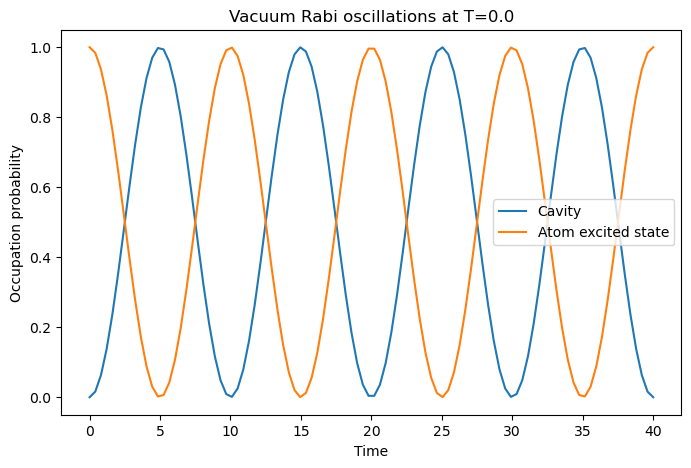

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tlist, output.expect[0], label="Cavity")
ax.plot(tlist, output.expect[1], label="Atom excited state")
ax.legend()
ax.set_xlabel("Time")
ax.set_ylabel("Occupation probability")
ax.set_title("Vacuum Rabi oscillations at T={}".format(n_th_a));

In [26]:
lamb = np.linspace(0,1,50)
theta = np.linspace(0,1,50)

eps = 2
g = 3
beta_a = 1
beta_b = 2
beta = 1.5
t = np.linspace(0,1,1000)

mat_crea2 = np.array([[0,0],[1,0]])
mat_anni2 = np.array([[0,1],[0,0]]) 
mat_id2 = np.identity(2)

mat_crea3 = np.array([[0,0,0],[1,0,0],[0,np.sqrt(2),0]])
mat_anni3 = np.array([[0,1,0],[0,0,np.sqrt(2)],[0,0,0]])
mat_id3 = np.identity(3)

diag_Ham = np.kron(np.kron(mat_id2,mat_id2),[[0,0,0],[0,1,0],[0,0,2]])
diag_Ham += np.kron(np.kron(mat_id2,[[0,0],[0,1]]),mat_id3)
diag_Ham += np.kron(np.kron([[0,0],[0,1]],mat_id2),mat_id3)

diag_Ham *= eps


offdiag_Ham1 = g * np.kron(np.kron(mat_crea2,mat_id2),mat_anni3)
offdiag_Ham2 = g * np.kron(np.kron(mat_anni2,mat_id2),mat_crea3)
offdiag_Ham3 = g * np.kron(np.kron(mat_id2,mat_crea2),mat_anni3)
offdiag_Ham4 = g * np.kron(np.kron(mat_id2,mat_anni2),mat_crea3)

offdiag_Ham = offdiag_Ham1 + offdiag_Ham2 + offdiag_Ham3 + offdiag_Ham4

Ham = diag_Ham + offdiag_Ham

In [ ]:
import qutip as qt

# --- 1. 기존 파라미터 및 해밀토니안 가져오기 (박사님 코드 설정 가정) ---
# 박사님 코드의 변수들을 그대로 활용합니다.
# eps=2, g=3 등은 위쪽 셀에서 정의되었다고 가정합니다.

# QuTiP 객체로 변환 (차원: A(2) x B(2) x C(3))
# 주의: Tensor product 순서가 중요합니다. 박사님 코드의 Ham 구조에 맞춰야 합니다.
# Ham 구성을 보니 np.kron(np.kron(A, B), C) 순서인 것 같습니다.
# 차원: [2, 2, 3]
dims = [2, 2, 3]
H_qobj = qt.Qobj(Ham)

# 초기 상태 (rho_AB * omega_C)
# 예시로 lambda, theta 인덱스 0,0 을 사용합니다. 필요에 따라 변경하세요.
rho_AB_val = Cal_rho(0, 0) 
# omega_C는 초기화가 필요합니다. (논문에서는 Fixed point를 찾아야 하지만, 여기선 예시로 바닥상태 가정)
omega_C_val = np.zeros((3, 3)); omega_C_val[0, 0] = 1 
rho_total_np = np.kron(rho_AB_val, omega_C_val)
rho_total_q = qt.Qobj(rho_total_np, dims=dims, shape=(12, 12))

# --- 2. 비교 분석: 마르코브 근사 (Lindblad) vs 유니터리 (Exact) ---

# 시간 설정 (0부터 tau까지)
tau = 1.0 # 예시 시간
tlist = np.linspace(0, tau, 100)

# Case 1: 마르코브 근사 적용 (Open System)
# 예: 캐비티(C)에서 광자가 손실되는 상황 (kappa > 0)
kappa = 0.5 # 붕괴율 (0이면 Case 2와 동일해짐)
a_op = qt.tensor(qt.qeye(2), qt.qeye(2), qt.destroy(3)) # C의 소멸 연산자
c_ops = [np.sqrt(kappa) * a_op] # 붕괴 연산자 리스트

# Lindblad Master Equation 풀기 (solvers.mesolve)
result_lindblad = qt.mesolve(H_qobj, rho_total_q, tlist, c_ops, [])
rho_final_lindblad = result_lindblad.states[-1] # 최종 상태

# Case 2: 마르코브 근사 미적용 (Closed System, Unitary)
# 붕괴 연산자 없음 (c_ops = [])
# 이는 논문의 (10)번 식 U * rho * U_dag 와 동일합니다.
result_unitary = qt.mesolve(H_qobj, rho_total_q, tlist, [], []) # c_ops 비움
rho_final_unitary = result_unitary.states[-1]

# --- 3. Partial Trace 및 A의 거동 확인 ---

# 시스템 A만 남기기 (인덱스 0번만 남기고 1(B), 2(C)를 Trace out)
rho_A_lindblad = rho_final_lindblad.ptrace(0)
rho_A_unitary = rho_final_unitary.ptrace(0)

# A의 에너지(또는 점유수) 계산을 위한 연산자
H_A_single = qt.Qobj(np.array([[0, 0], [0, eps]])) # A의 해밀토니안 (박사님 정의에 따름)
E_A_lindblad = qt.expect(H_A_single, rho_A_lindblad)
E_A_unitary = qt.expect(H_A_single, rho_A_unitary)

print(f"--- 결과 비교 (tau={tau}) ---")
print(f"1. 마르코브 근사 (kappa={kappa}): E_A = {E_A_lindblad:.6f}")
print(f"2. 유니터리 진화 (kappa=0):   E_A = {E_A_unitary:.6f}")
print(f"차이: {abs(E_A_lindblad - E_A_unitary):.6f}")

# --- 4. 시각화 (A의 에너지 시간 변화) ---
E_A_t_lindblad = [qt.expect(H_A_single, state.ptrace(0)) for state in result_lindblad.states]
E_A_t_unitary = [qt.expect(H_A_single, state.ptrace(0)) for state in result_unitary.states]

plt.figure(figsize=(10, 6))
plt.plot(tlist, E_A_t_unitary, label='Unitary (Eq. 10, No Approx)', linewidth=2)
plt.plot(tlist, E_A_t_lindblad, '--', label=f'Lindblad (Eq. 8 + Dissipation k={kappa})', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Energy of System A')
plt.title('Dynamics of System A: Unitary vs Markovian')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'Cal_rho' is not defined

: 

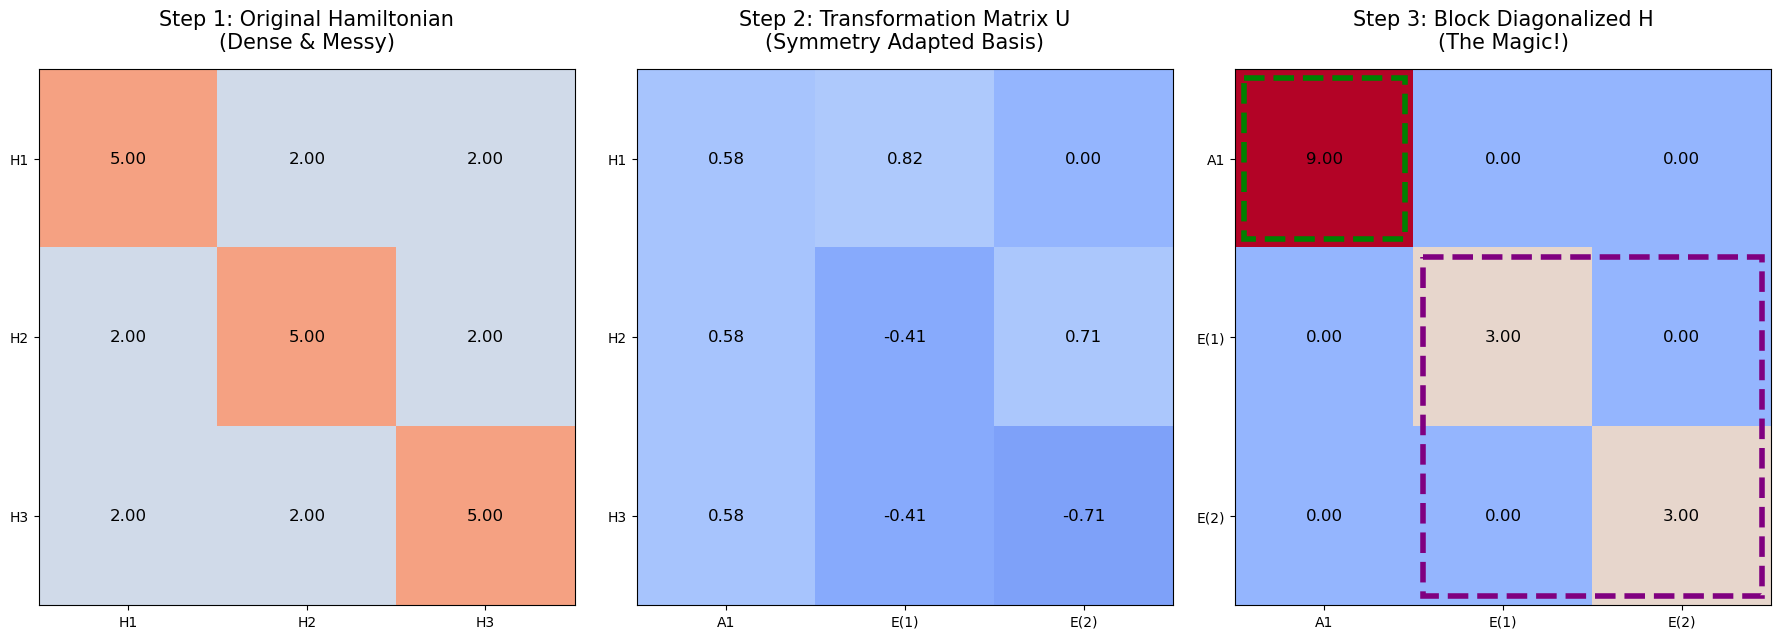

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 설정: 3개의 수소 원자 시스템 (암모니아 바닥)
# 대칭성을 가진 Hamiltonian (상호작용 행렬) 정의
# 대각선(Self-energy)은 같고, 비대각선(Interaction)도 모두 같아야 C3v 대칭입니다.
# H = [[a, b, b],
#      [b, a, b],
#      [b, b, a]]
a = 5.0  # 자체 에너지
b = 2.0  # 상호작용 에너지
H_original = np.array([[a, b, b],
                       [b, a, b],
                       [b, b, a]])

# 2. 기저 벡터 정의 (우리가 구한 SAB)
# 2-1. A1 모드 (전체 대칭, Breathing Mode)
v_A1 = np.array([1, 1, 1])

# 2-2. E 모드 (User가 찾아낸 2중 축퇴 모드)
# v_E1: (2, -1, -1) -> 정규화 필요
v_E1 = np.array([2, -1, -1])
# v_E2: (0, 1, -1) -> 정규화 필요
v_E2 = np.array([0, 1, -1])

# 3. 정규화 (Normalization) - 양자역학의 기본 매너
def normalize(v):
    return v / np.linalg.norm(v)

v_A1 = normalize(v_A1)
v_E1 = normalize(v_E1)
v_E2 = normalize(v_E2)

# 4. 변환 행렬 U 생성 (Transformation Matrix)
# 열(Column) 벡터로 쌓습니다.
U = np.column_stack((v_A1, v_E1, v_E2))

# 5. 기저 변환 수행 (Similarity Transformation)
# H_new = U_dagger * H * U
H_diagonalized = U.T @ H_original @ U

# ==========================================
# 6. 시각화 (Visualization)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 공통 플롯 설정
cmap = 'coolwarm' # 빨강(+), 파랑(-), 흰색(0)
def plot_matrix(ax, matrix, title):
    im = ax.imshow(matrix, cmap=cmap, vmin=-3, vmax=8) # 색상 범위 고정
    ax.set_title(title, fontsize=15, pad=15)
    # 각 셀에 숫자 표시
    for (j, i), label in np.ndenumerate(matrix):
        ax.text(i, j, f'{label:.2f}', ha='center', va='center', color='black', fontsize=12)
    # 축 눈금 제거 및 라벨링
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    
# Step 1: 원래 해밀토니안
plot_matrix(axes[0], H_original, "Step 1: Original Hamiltonian\n(Dense & Messy)")
axes[0].set_xticklabels(['H1', 'H2', 'H3'])
axes[0].set_yticklabels(['H1', 'H2', 'H3'])

# Step 2: 변환 행렬 U (SAB)
plot_matrix(axes[1], U, "Step 2: Transformation Matrix U\n(Symmetry Adapted Basis)")
axes[1].set_xticklabels(['A1', 'E(1)', 'E(2)'])
axes[1].set_yticklabels(['H1', 'H2', 'H3'])

# Step 3: 대각화된 결과
plot_matrix(axes[2], H_diagonalized, "Step 3: Block Diagonalized H\n(The Magic!)")
axes[2].set_xticklabels(['A1', 'E(1)', 'E(2)'])
axes[2].set_yticklabels(['A1', 'E(1)', 'E(2)'])

# 하이라이트 박스 그리기 (블록 대각화 강조)
from matplotlib.patches import Rectangle
# A1 블록 (1x1)
axes[2].add_patch(Rectangle((-0.45, -0.45), 0.9, 0.9, fill=False, edgecolor='green', lw=4, linestyle='--'))
# E 블록 (2x2)
axes[2].add_patch(Rectangle((0.55, 0.55), 1.9, 1.9, fill=False, edgecolor='purple', lw=4, linestyle='--'))

plt.tight_layout()
plt.show()

C:\Users\128kbps\AppData\Local\Temp\ipykernel_44016\2479440067.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


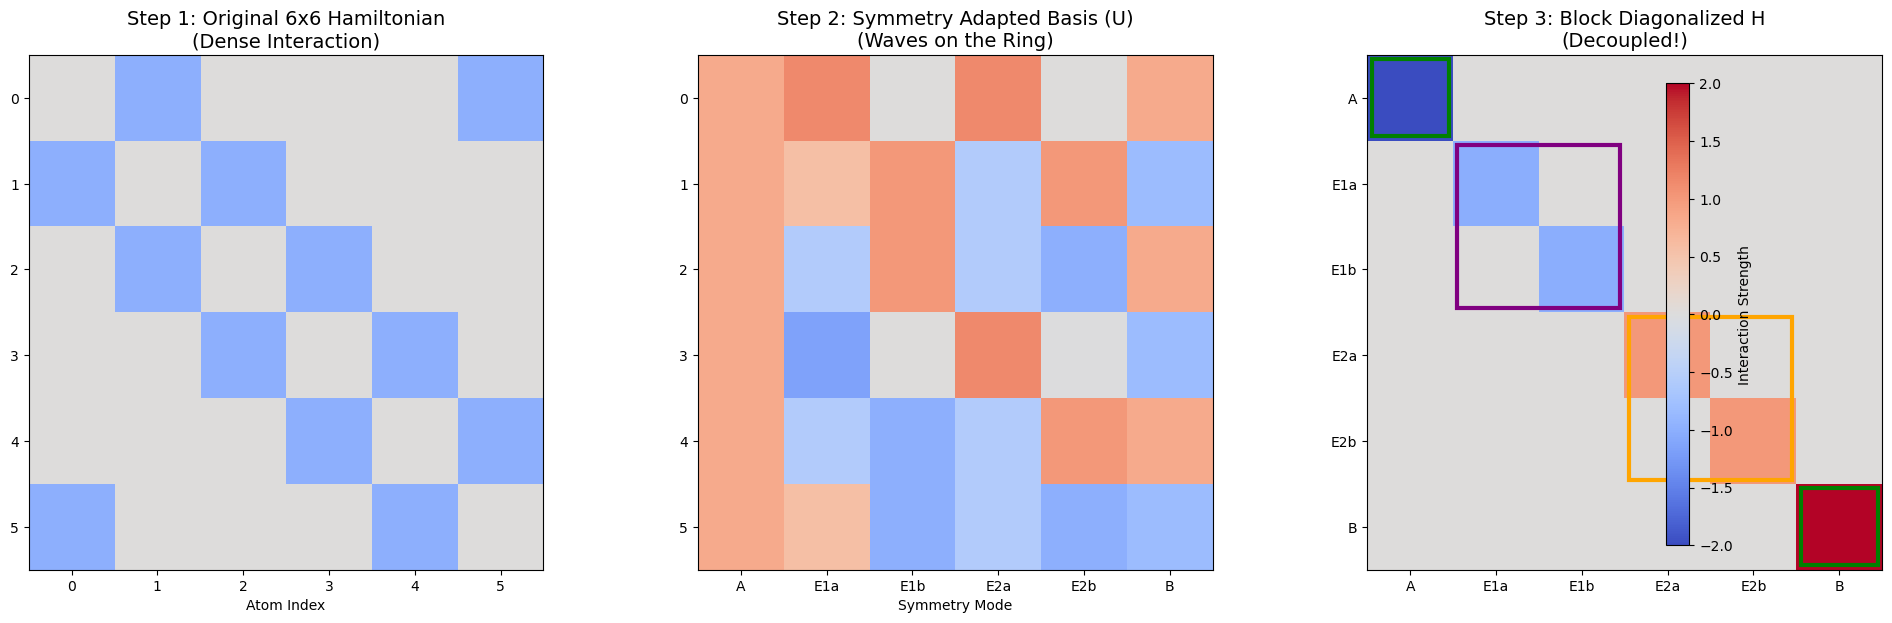

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 시스템 설정: 6-site Ring (Benzene-like)
# ==========================================
N = 6
# Hamiltonian H:
# - 대각선(Self energy): 0 (기준점)
# - 이웃간 상호작용(Hopping): -1.0
# - 주기적 경계 조건 (1번과 6번 연결)
H = np.zeros((N, N))
t = -1.0  # Hopping interaction

for i in range(N):
    H[i, i] = 0.0           # Self energy
    H[i, (i+1)%N] = t       # Right neighbor
    H[i, (i-1)%N] = t       # Left neighbor

# ==========================================
# 2. Symmetry Adapted Basis (SAB) 구성
# ==========================================
# 6개의 원자가 만드는 파동(Wave)을 만듭니다.
# 이것은 Bloch Theorem이나 이산 푸리에 변환(DFT)과 원리가 같습니다.

# k=0: 위상 변화 없음 (++++++) -> A 모드 (1개)
v_A = np.array([1, 1, 1, 1, 1, 1])

# k=3: 부호가 교대로 바뀜 (+-+-+-) -> B 모드 (1개)
v_B = np.array([1, -1, 1, -1, 1, -1])

# k=1: 파장 긴 코사인/사인 쌍 -> E1 모드 (2개, 축퇴됨)
theta1 = 2 * np.pi * 1 * np.arange(N) / N
v_E1_a = np.cos(theta1)
v_E1_b = np.sin(theta1)

# k=2: 파장 짧은 코사인/사인 쌍 -> E2 모드 (2개, 축퇴됨)
theta2 = 2 * np.pi * 2 * np.arange(N) / N
v_E2_a = np.cos(theta2)
v_E2_b = np.sin(theta2)

# 기저 벡터 모음 (리스트)
basis_vectors = [v_A, v_E1_a, v_E1_b, v_E2_a, v_E2_b, v_B]

# 3. 정규화 (Normalization) & 행렬화
def normalize(v):
    return v / np.linalg.norm(v)

U = np.column_stack([normalize(v) for v in basis_vectors])

# 4. 기저 변환 (Similarity Transformation)
# H_new = U.T * H * U
H_block = U.T @ H @ U

# 0에 가까운 값은 깔끔하게 0으로 처리 (시각화를 위해)
H_block[np.abs(H_block) < 1e-10] = 0

# ==========================================
# 5. 시각화 (Visualization)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cmap = 'coolwarm' 
v_max = 2.0 # 색상 범위 통일

# Plot 1: Original H
im1 = axes[0].imshow(H, cmap=cmap, vmin=-v_max, vmax=v_max)
axes[0].set_title(f"Step 1: Original {N}x{N} Hamiltonian\n(Dense Interaction)", fontsize=14)
axes[0].set_xticks(range(N)); axes[0].set_yticks(range(N))
axes[0].set_xlabel("Atom Index")

# Plot 2: Transformation Matrix U
im2 = axes[1].imshow(U, cmap=cmap, vmin=-1, vmax=1)
axes[1].set_title("Step 2: Symmetry Adapted Basis (U)\n(Waves on the Ring)", fontsize=14)
axes[1].set_xticks(range(N)); axes[1].set_yticks(range(N))
axes[1].set_xticklabels(['A', 'E1a', 'E1b', 'E2a', 'E2b', 'B'])
axes[1].set_xlabel("Symmetry Mode")

# Plot 3: Block Diagonalized H
im3 = axes[2].imshow(H_block, cmap=cmap, vmin=-v_max, vmax=v_max)
axes[2].set_title("Step 3: Block Diagonalized H\n(Decoupled!)", fontsize=14)
axes[2].set_xticks(range(N)); axes[2].set_yticks(range(N))
axes[2].set_xticklabels(['A', 'E1a', 'E1b', 'E2a', 'E2b', 'B'])
axes[2].set_yticklabels(['A', 'E1a', 'E1b', 'E2a', 'E2b', 'B'])

# Add Boxes to highlight blocks
from matplotlib.patches import Rectangle
# A block (1x1)
axes[2].add_patch(Rectangle((-0.45, -0.45), 0.9, 0.9, fill=False, edgecolor='green', lw=3))
# E1 block (2x2)
axes[2].add_patch(Rectangle((0.55, 0.55), 1.9, 1.9, fill=False, edgecolor='purple', lw=3))
# E2 block (2x2)
axes[2].add_patch(Rectangle((2.55, 2.55), 1.9, 1.9, fill=False, edgecolor='orange', lw=3))
# B block (1x1)
axes[2].add_patch(Rectangle((4.55, 4.55), 0.9, 0.9, fill=False, edgecolor='green', lw=3))

# Colorbar
cbar = fig.colorbar(im1, ax=axes, fraction=0.02, pad=0.04)
cbar.set_label('Interaction Strength')

plt.tight_layout()
plt.show()

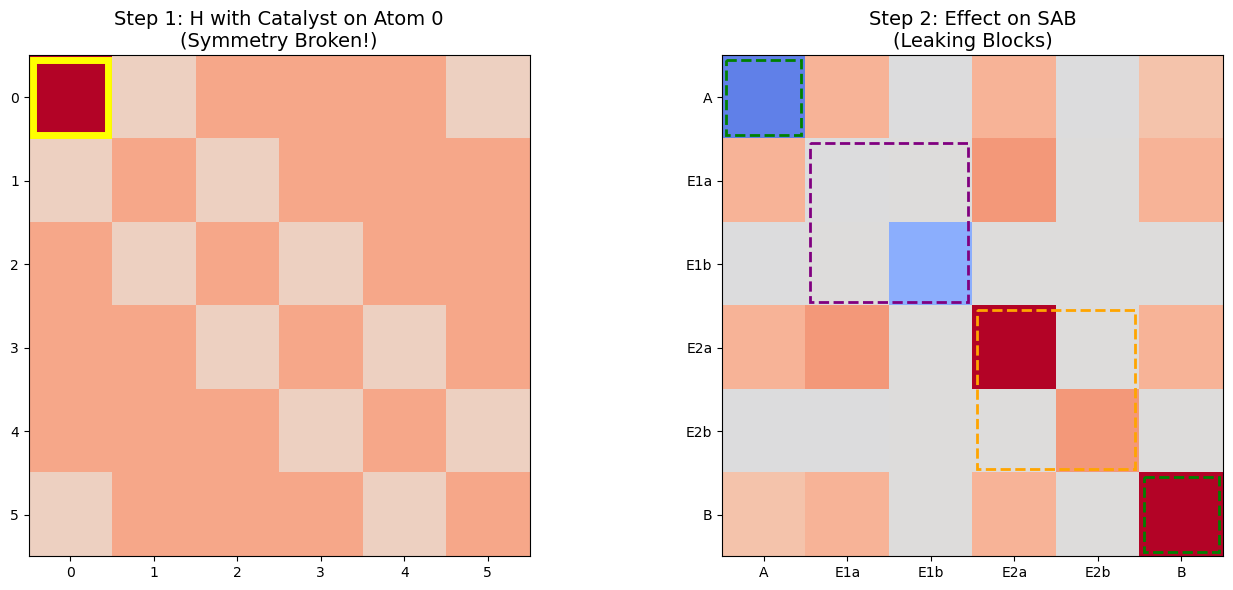

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1. 시스템 설정 (N=6 Ring)
N = 6
H = np.zeros((N, N))
t = -1.0 

# 기본 상호작용
for i in range(N):
    H[i, (i+1)%N] = t
    H[i, (i-1)%N] = t

# ==========================================
# 🔥 CHANGE: 촉매(Impurity) 추가!
# ==========================================
# 0번 원자에 강력한 촉매가 붙어서 에너지를 변화시킴 (Symmetry Breaking)
H[0, 0] = 3.0 

# 2. 기존의 Symmetry Adapted Basis (SAB) 그대로 사용
# (대칭성이 깨지기 전의 관점으로 이 시스템을 바라봄)
v_A = np.array([1, 1, 1, 1, 1, 1])
v_B = np.array([1, -1, 1, -1, 1, -1])
theta1 = 2 * np.pi * 1 * np.arange(N) / N
v_E1_a = np.cos(theta1); v_E1_b = np.sin(theta1)
theta2 = 2 * np.pi * 2 * np.arange(N) / N
v_E2_a = np.cos(theta2); v_E2_b = np.sin(theta2)

basis_vectors = [v_A, v_E1_a, v_E1_b, v_E2_a, v_E2_b, v_B]

def normalize(v): return v / np.linalg.norm(v)
U = np.column_stack([normalize(v) for v in basis_vectors])

# 3. 변환 수행
H_block_broken = U.T @ H @ U

# ==========================================
# 4. 시각화
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = 'coolwarm'
v_max = 2.0

# Plot 1: 촉매가 붙은 원래 Hamiltonian
im1 = axes[0].imshow(H, cmap=cmap, vmin=-5, vmax=2)
axes[0].set_title("Step 1: H with Catalyst on Atom 0\n(Symmetry Broken!)", fontsize=14)
axes[0].set_xticks(range(N)); axes[0].set_yticks(range(N))
# 0번 원자 강조
axes[0].add_patch(Rectangle((-0.45, -0.45), 0.9, 0.9, fill=False, edgecolor='yellow', lw=5))

# Plot 2: 깨진 블록 대각화
im2 = axes[1].imshow(H_block_broken, cmap=cmap, vmin=-v_max, vmax=v_max)
axes[1].set_title("Step 2: Effect on SAB\n(Leaking Blocks)", fontsize=14)
axes[1].set_xticks(range(N)); axes[1].set_yticks(range(N))
axes[1].set_xticklabels(['A', 'E1a', 'E1b', 'E2a', 'E2b', 'B'])
axes[1].set_yticklabels(['A', 'E1a', 'E1b', 'E2a', 'E2b', 'B'])

# 원래 블록 위치 표시 (이제는 의미가 퇴색됨)
axes[1].add_patch(Rectangle((-0.45, -0.45), 0.9, 0.9, fill=False, edgecolor='green', lw=2, linestyle='--'))
axes[1].add_patch(Rectangle((0.55, 0.55), 1.9, 1.9, fill=False, edgecolor='purple', lw=2, linestyle='--'))
axes[1].add_patch(Rectangle((2.55, 2.55), 1.9, 1.9, fill=False, edgecolor='orange', lw=2, linestyle='--'))
axes[1].add_patch(Rectangle((4.55, 4.55), 0.9, 0.9, fill=False, edgecolor='green', lw=2, linestyle='--'))

plt.tight_layout()
plt.show()

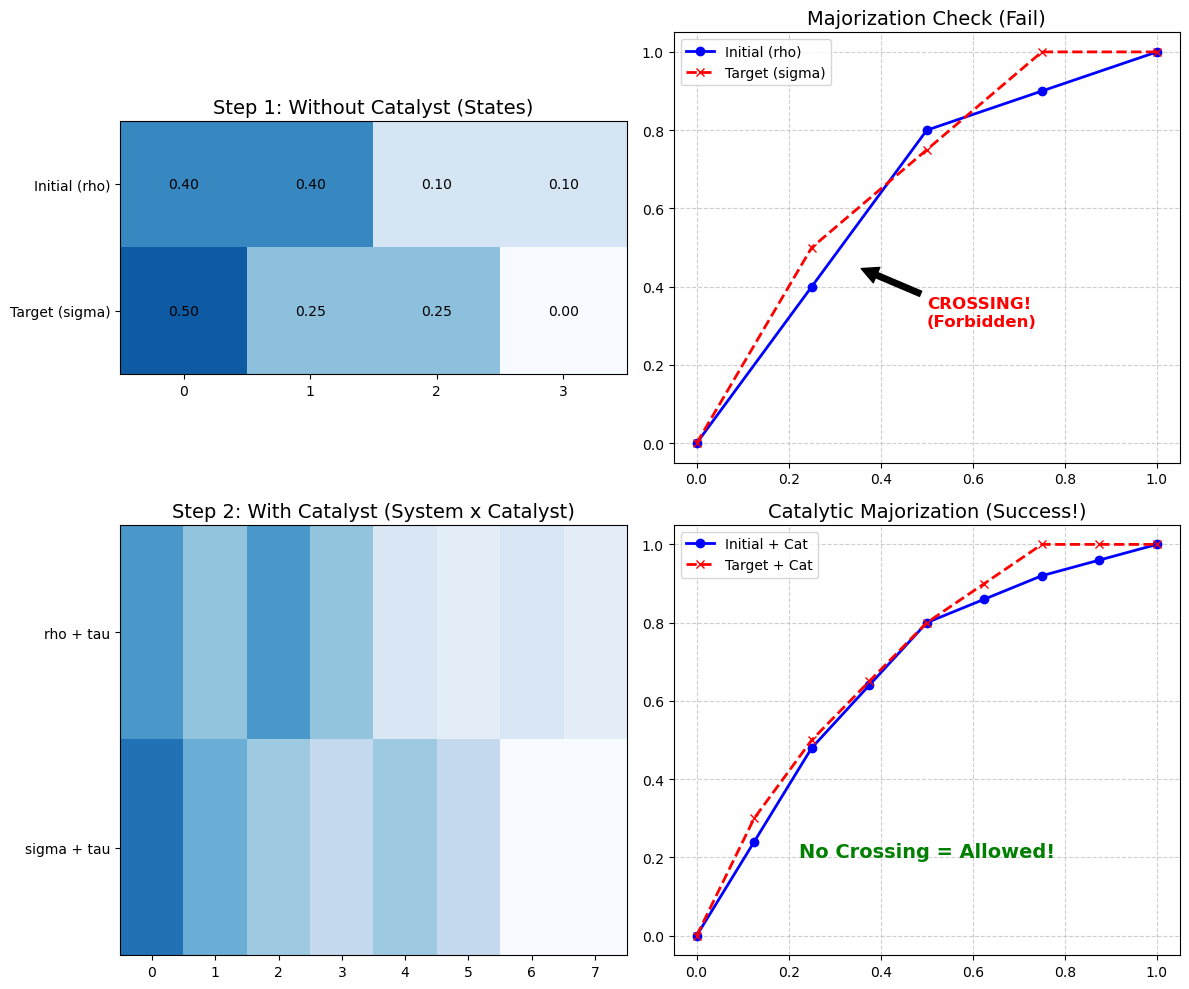

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 상태 설정 (Probability Distributions)
# ==========================================
# 에너지 준위에 전자가 찰 확률(밀도 행렬의 대각 성분)이라고 생각하세요.

# 초기 상태 (rho): 약간 퍼져 있음
rho = np.array([0.4, 0.4, 0.1, 0.1])

# 목표 상태 (sigma): 더 뾰족함 (더 낮은 온도로 가고 싶음)
sigma = np.array([0.5, 0.25, 0.25, 0.0])

# 촉매 (tau): 6:4 비율의 보조계
tau = np.array([0.6, 0.4])

# ==========================================
# 2. 계산 함수: 로렌츠 곡선 (Lorenz Curve)
# ==========================================
def get_lorenz_curve(prob_dist):
    # 1. 내림차순 정렬 (큰 확률부터 쌓아야 함)
    sorted_prob = np.sort(prob_dist)[::-1]
    # 2. 누적 합 계산 (Cumulative Sum)
    cum_prob = np.cumsum(sorted_prob)
    # 3. 그래프 그리기 좋게 0부터 시작하게 맞춤
    return np.concatenate(([0], cum_prob))

# ==========================================
# 3. 촉매 결합 (Kronecker Product)
# ==========================================
# 시스템(4차원) x 촉매(2차원) = 전체(8차원)
rho_with_catalyst = np.kron(rho, tau)
sigma_with_catalyst = np.kron(sigma, tau)

# ==========================================
# 4. 시각화
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmap = 'Blues'

# --- [상단] 촉매 없을 때 (Fail) ---

# 1. 상태 분포 시각화 (imshow)
axes[0, 0].imshow([rho, sigma], cmap=cmap, vmin=0, vmax=0.6)
axes[0, 0].set_title("Step 1: Without Catalyst (States)", fontsize=14)
axes[0, 0].set_yticks([0, 1])
axes[0, 0].set_yticklabels(['Initial (rho)', 'Target (sigma)'])
axes[0, 0].set_xticks(range(4))
for (j, i), label in np.ndenumerate([rho, sigma]):
    axes[0, 0].text(i, j, f'{label:.2f}', ha='center', va='center', color='black')

# 2. 로렌츠 곡선 비교 (Plot)
lorenz_rho = get_lorenz_curve(rho)
lorenz_sigma = get_lorenz_curve(sigma)
x_axis = np.linspace(0, 1, len(lorenz_rho))

axes[0, 1].plot(x_axis, lorenz_rho, 'b-o', label='Initial (rho)', linewidth=2)
axes[0, 1].plot(x_axis, lorenz_sigma, 'r--x', label='Target (sigma)', linewidth=2)
axes[0, 1].set_title("Majorization Check (Fail)", fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# 교차점 강조 (Crossing means Impossible)
axes[0, 1].annotate('CROSSING!\n(Forbidden)', xy=(0.35, 0.45), xytext=(0.5, 0.3),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, color='red', fontweight='bold')


# --- [하단] 촉매 있을 때 (Success) ---

# 3. 결합된 상태 분포 (imshow)
# 8차원이므로 1x8로 표현
axes[1, 0].imshow([rho_with_catalyst, sigma_with_catalyst], cmap=cmap, vmin=0, vmax=0.4)
axes[1, 0].set_title("Step 2: With Catalyst (System x Catalyst)", fontsize=14)
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_yticklabels(['rho + tau', 'sigma + tau'])
axes[1, 0].set_aspect('auto') # 비율 자동 조정

# 4. 로렌츠 곡선 비교 (Plot)
lorenz_rho_cat = get_lorenz_curve(rho_with_catalyst)
lorenz_sigma_cat = get_lorenz_curve(sigma_with_catalyst)
x_axis_cat = np.linspace(0, 1, len(lorenz_rho_cat))

axes[1, 1].plot(x_axis_cat, lorenz_rho_cat, 'b-o', label='Initial + Cat', linewidth=2)
axes[1, 1].plot(x_axis_cat, lorenz_sigma_cat, 'r--x', label='Target + Cat', linewidth=2)
axes[1, 1].set_title("Catalytic Majorization (Success!)", fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# 성공 강조
axes[1, 1].text(0.5, 0.2, "No Crossing = Allowed!", ha='center', fontsize=14, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

찾아낸 보존량의 개수 (Dimension of J): 4


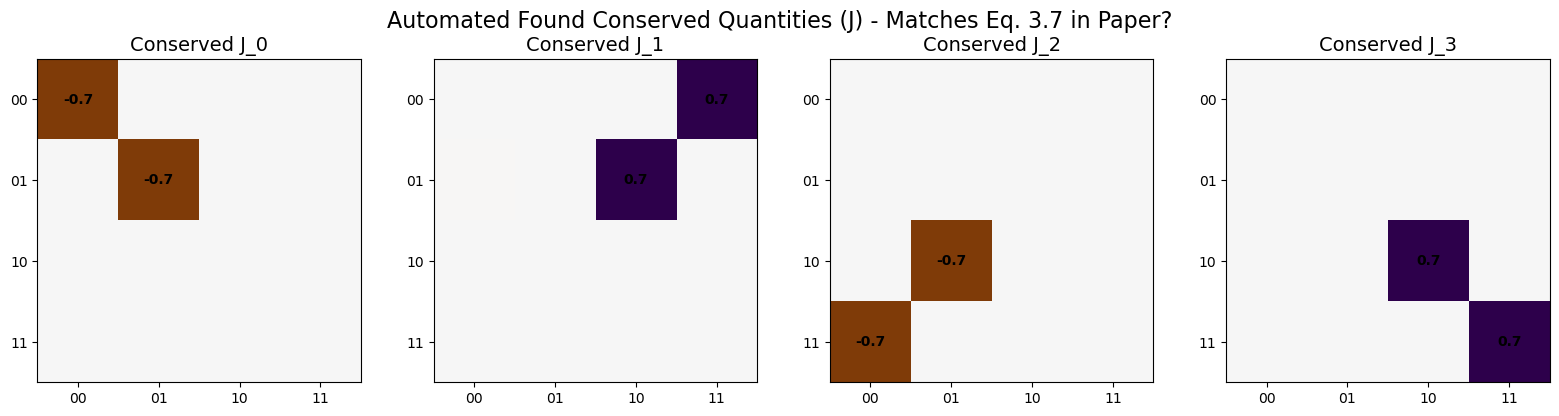

In [11]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

# ==========================================
# 1. 기본 연산자 정의 (Pauli Matrices)
# ==========================================
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

# Kronecker Product helper
def kron(A, B): return np.kron(A, B)

# ==========================================
# 2. 시스템 설정: 논문 Sec III.B Two-Qubit DFS
# ==========================================
# Jump Operator F = 0.5 * (I - Z1 Z2) * X2  [Eq. 3.3 in Paper]
Z1Z2 = kron(Z, Z)
X2 = kron(I, X)
F = 0.245 * (np.eye(4) - Z1Z2) @ X2

# Hamiltonian H = 0 (논문 설정)
H = np.zeros((4, 4))

# ==========================================
# 3. Liouvillian Superoperator 구성 [Eq. A2 in Paper]
# ==========================================
# L(rho) -> vector form L_mat * vec(rho)
# L = -i[H, .] + 2F.Fdag - {FdagF, .}

Id = np.eye(4)
# Dissipator parts
F_dag = F.conj().T
FF = F_dag @ F

# Superoperator matrix construction
# Term 1: 2 * F * rho * F_dag  ->  2 * (F* kron F)
# Term 2: - F_dag * F * rho    ->  - I kron (F_dag F).T
# Term 3: - rho * F_dag * F    ->  - (F_dag F) kron I
# (Note: Python's kron is A kron B, vectorization is usually row-major or col-major. 
# Here we stick to standard physics convention: vec(ABC) = (C^T kron A) vec(B) 
# but for simplicity in self-consistent code, we use explicit index mapping or simple construction)

def get_superoperator(H, Jump_ops):
    dim = H.shape[0]
    dim_sq = dim**2
    L_super = np.zeros((dim_sq, dim_sq), dtype=complex)
    
    # Hamiltonian part: -i[H, rho]
    # H rho - rho H
    L_H = -1j * (np.kron(Id, H) - np.kron(H.T, Id)) # Using H.T for right multiplication logic
    
    L_super += L_H
    
    for L in Jump_ops:
        L_dag = L.conj().T
        L_dag_L = L_dag @ L
        
        # 2 L rho L^dag
        term1 = 2 * np.kron(L.conj(), L) # Check convention: often L_bar kron L
        
        # - {L^dag L, rho}
        term2 = - (np.kron(Id, L_dag_L) + np.kron(L_dag_L.T, Id))
        
        L_super += term1 + term2
        
    return L_super

# Re-implementing strictly following paper's Eq A2 for clarity
# Paper A2: L = -i(H x I - I x H*) + sum (2 L x L* - LdagL x I - I x (LdagL)*)
# Note: Paper uses |rho>> convention.
def build_liouvillian_paper_A2(H, F_list):
    dim = H.shape[0]
    I_sys = np.eye(dim)
    
    # Hamiltonian part
    L_mat = -1j * (np.kron(I_sys, H) - np.kron(H.conj(), I_sys)) 
    
    for F in F_list:
        F_dag = F.conj().T
        FdF = F_dag @ F
        
        # Dissipator: 2 F x F* - FdF x I - I x (FdF)*
        L_diss = 2 * np.kron(F.conj(), F) - np.kron(I_sys, FdF) - np.kron(FdF.conj(), I_sys)
        L_mat += L_diss
        
    return L_mat

# Build it
L_mat = build_liouvillian_paper_A2(H, [F])

# ==========================================
# 4. 보존량 (Conserved Quantities) 찾기
# ==========================================
# Condition: L_dag(J) = 0  =>  L_mat.conj().T * vec(J) = 0
L_mat_dag = L_mat.conj().T

# Find Null Space (Kernel)
null_space = scipy.linalg.null_space(L_mat_dag)
# null_space returns unitary basis for the kernel

print(f"찾아낸 보존량의 개수 (Dimension of J): {null_space.shape[1]}")

# ==========================================
# 5. 결과 시각화 및 검증
# ==========================================
# 찾아낸 Basis를 4x4 행렬로 변환하여 시각화
num_conserved = null_space.shape[1]
fig, axes = plt.subplots(1, num_conserved, figsize=(4*num_conserved, 4))
if num_conserved == 1: axes = [axes]

fig.suptitle(f"Automated Found Conserved Quantities (J) - Matches Eq. 3.7 in Paper?", fontsize=16)

for i in range(num_conserved):
    vec_J = null_space[:, i]
    # Reshape back to matrix (4x4)
    # Caution: reshape order depends on vectorization convention. 
    # Paper uses standard column-stacking or row-stacking. Let's try standard.
    mat_J = vec_J.reshape((4, 4)) 
    
    # Plot real part (Conserved quantities are often Hermitian or can be made so)
    ax = axes[i]
    im = ax.imshow(np.real(mat_J), cmap='PuOr', vmin=-0.5, vmax=0.5)
    ax.set_title(f"Conserved J_{i}", fontsize=14)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(['00','01','10','11'])
    ax.set_yticklabels(['00','01','10','11'])
    
    # Annotate values
    for (y, x), val in np.ndenumerate(np.real(mat_J)):
        if abs(val) > 1e-2:
            ax.text(x, y, f"{val:.1f}", ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

c:\Users\128kbps\anaconda3\envs\workspace\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


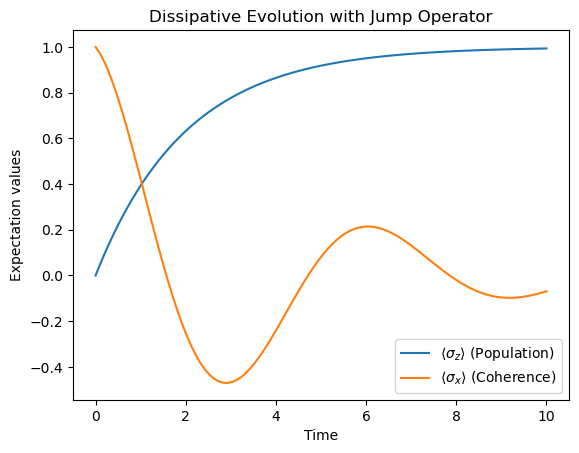

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# 1. 파라미터 설정
omega = 1.0  # 시스템 에너지 레벨 차이 (H)
gamma = 0.5  # 감쇠율 (환경과의 상호작용 세기)

# 2. Hamiltonian & Initial State 설정
# H = (omega/2) * sigma_z
H = 0.5 * omega * sigmaz()

# 초기 상태: 들뜬 상태와 바닥 상태의 중첩 (|0> + |1>) / sqrt(2)
# 시간이 지나면 결맞음(Coherence)이 사라지고 바닥 상태로 가야 함
psi0 = (basis(2, 0) + basis(2, 1)).unit()

# 3. Jump Operator 정의 (핵심)
# 시스템의 에너지를 낮추는 연산자 (Annihilation / Lowering operator)
# L = sqrt(gamma) * sigma_minus
# QuTiP에서 destroy(2)는 2-level system의 소멸 연산자(sigma_-)와 같음
L1 = np.sqrt(gamma) * destroy(2)

c_ops = [L1]  # 여러 개일 경우 리스트에 추가

# 4. 시간 발전 (Lindblad Master Equation 풀기)
times = np.linspace(0, 10, 100)
result = mesolve(H, psi0, times, c_ops, [sigmaz(), sigmax()])

# 5. 결과 시각화
fig, ax = plt.subplots()
ax.plot(times, result.expect[0], label=r'$\langle \sigma_z \rangle$ (Population)')
ax.plot(times, result.expect[1], label=r'$\langle \sigma_x \rangle$ (Coherence)')
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
ax.legend()
ax.set_title('Dissipative Evolution with Jump Operator')
plt.show()

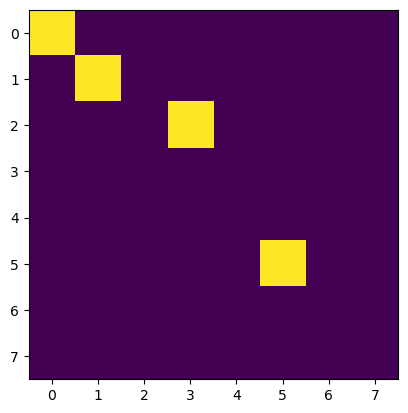

In [7]:
block = np.zeros((8,8))

block[0,0]=1
block[1,1]=1
block[2,3]=1
block[5,5]=1

plt.imshow(block)
plt.show()

유니터리 구현

In [1]:
import numpy as np
import scipy as sp
import qutip as qt
import pandas as pd
import cvxpy as cp

np.set_printoptions(precision=4, suppress=True ,linewidth=np.inf, floatmode='fixed')


import matplotlib.pyplot as plt

In [54]:
H_A = np.random.rand(2,2)
H_B = np.random.rand(3,3)

rho_AB = np.kron(H_A,H_B)

tol = 1e-9

In [55]:
dim_A = H_A.shape[0]
dim_B = H_B.shape[0]

dim_tot = dim_A * dim_B

In [56]:
I_A = np.eye(dim_A)
I_B = np.eye(dim_B)

In [57]:
H_tot = np.kron(H_A,I_B) + np.kron(I_A,H_B)
H_A_tot = np.kron(H_A, I_B)

In [58]:
eigvals_tot , eigvecs_tot = np.linalg.eigh(H_tot)

In [ ]:
energies_rounded = np.round(eigvals_tot/tol) * tol # degenerated 되어 있는 전체 eigenval
unique_energies = np.unique(energies_rounded) # degenerate를 제외하고 eigenvalue의 종류

In [60]:
U_opt = np.zeros((dim_tot, dim_tot),dtype = complex)

In [ ]:
for E in unique_energies:
    indices = np.where(np.abs(energies_rounded - E < tol))[0]
    #print(indices)

    if len(indices) == 0:
        continue

    subspace_basis = eigvecs_tot[:,indices]

    rho_block = subspace_basis.conj().T @ rho_AB @ subspace_basis

    p_nu,v_rho = np.linalg.eigh(rho_block)

    sorted_p_indices = np.argsort(p_nu)[::-1]
    p_nu_sorted = p_nu[sorted_p_indices]
    v_rho_sorted = v_rho[:,sorted_p_indices]

    # rho의 고유상태들
    phi_n_states = subspace_basis @ v_rho_sorted

    H_A_block = subspace_basis.conj().T @ H_A_tot @ subspace_basis
    e_A_vals,v_HA = np.linalg.eigh(H_A_block)

    sorted_e_indices = np.argsort(e_A_vals)
    e_A_sorted = e_A_vals[sorted_e_indices]
    v_HA_sorted = v_HA[:,sorted_e_indices]

    # 전체 힐메르트 공간에서 정렬된 에너지 기저들
    epsilon_n_states = subspace_basis @ v_HA_sorted
    
    U_sub = epsilon_n_states @ phi_n_states.conj().T
    #print(U_sub)

    U_opt += U_sub

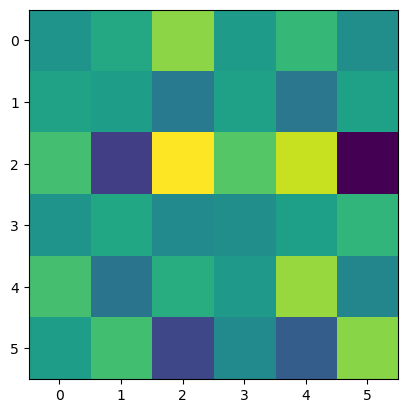

In [79]:
plt.imshow((U_opt.conj().T @ rho_AB @ U_opt).real)